In [11]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [12]:
class BatsmanState(TypedDict):
    
    runs: int
    balls: int
    fours: int
    sixes: int
    
    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [28]:
def calculate_sr(state: BatsmanState)-> BatsmanState:
    
    sr = (state['runs']/state['balls'])*100
    
    return {'sr': sr}

In [21]:
def calculate_bpb(state: BatsmanState)-> BatsmanState:
    
    bpb = state['balls']/(state['fours']+state['sixes'])
    
    return {'bpb': bpb}

In [22]:
def calculate_bper(state: BatsmanState)-> BatsmanState:
    
    bper = (((state['balls']*4) + (state['sixes']*6))/state['runs'])*100
    
    return {'boundary_percent': bper}

In [29]:
def calculate_summary(state: BatsmanState)-> BatsmanState:
    
    summary = f"""
    Strike Rate - {state['sr']} \n
    Balls per boundary - {state['bpb']} \n
    Boundary percent - {state['boundary_percent']}
    """
    
    return {'summary': summary}

In [30]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_bper', calculate_bper)
graph.add_node('summary', calculate_summary)

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_bper')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_bper', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

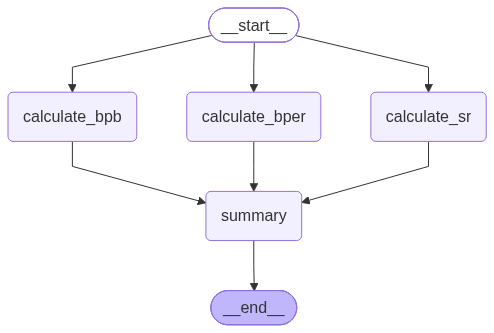

In [25]:
workflow

In [31]:
initial_state = {
    'runs':100,
    'balls':50,
    'fours':6,
    'sixes':4
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 224.00000000000003, 'summary': '\n    Strike Rate - 200.0 \n\n    Balls per boundary - 5.0 \n\n    Boundary percent - 224.00000000000003\n    '}


In [32]:
print(final_state['summary'])


    Strike Rate - 200.0 

    Balls per boundary - 5.0 

    Boundary percent - 224.00000000000003
    
